In [2]:
# Test 1: Identity Ablation (No VQC)

#**Purpose**: Replace the VQC with an identity mapping while keeping the dual encoders, fusion block, head input structure, residual path, data split, and evaluation pipeline aligned with the hybrid baseline.

#**Targets**: `log_H2O`, `log_CO2`, `log_CO`, `log_CH4`, `log_NH3`

## 1. Configuration

In [3]:
import json
import math
import os
import random
import time
from pathlib import Path

os.environ.setdefault("XDG_CACHE_HOME", str(Path("../.cache").resolve()))
os.environ.setdefault("MPLCONFIGDIR", str(Path("../.matplotlib-cache").resolve()))

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.model_selection import train_test_split

try:
    from tqdm.auto import tqdm
except ImportError:
    class _TqdmFallback:
        def __init__(self, iterable=None, total=None, desc=None, leave=True):
            self.iterable = iterable

        def __iter__(self):
            return iter(self.iterable)

        def set_postfix(self, **kwargs):
            pass

        @staticmethod
        def write(message):
            print(message)

    def tqdm(iterable=None, total=None, desc=None, leave=True):
        return _TqdmFallback(iterable=iterable, total=total, desc=desc, leave=leave)

AUX_FEATURE_COLS = [
    "star_mass_kg", "star_radius_m", "star_temperature",
    "planet_mass_kg", "planet_orbital_period", "planet_distance",
    "planet_surface_gravity", "log10_noise_mean",
]
TARGET_COLS = ["log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"]

SEED = 42
DATA_ROOT_CANDIDATES = [
    Path("../FullDataset"),
    Path("FullDataset"),
    Path("../ariel-ml-dataset"),
    Path("ariel-ml-dataset"),
]
OUTPUT_DIR = Path("../outputs/no_vqc_test1")
TRAIN_BATCH_SIZE = 256
EVAL_BATCH_SIZE = 8192
MAX_EPOCHS = 30
EARLY_STOP_PATIENCE = 6
SCHEDULER_PATIENCE = 5
CLASSICAL_LR = 2e-3
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP = 5.0
DROPOUT = 0.05
VAL_FRACTION = 0.10

AUX_HIDDEN = 64
AUX_OUT = 32
SPECTRAL_HIDDEN = 64
SPECTRAL_OUT = 32
FUSION_HIDDEN = 48
HEAD_HIDDEN = 96
LATENT_DIM = 12


def resolve_data_root(candidates):
    for root in candidates:
        train_dir = root / "TrainingData"
        if (train_dir / "AuxillaryTable.csv").exists() and (train_dir / "SpectralData.hdf5").exists():
            return root
    searched = "\n".join(f" - {path.resolve()}" for path in candidates)
    raise FileNotFoundError(
        "Could not locate the Ariel dataset. Put the extracted dataset in one of:\n"
        f"{searched}"
    )


DATA_ROOT = resolve_data_root(DATA_ROOT_CANDIDATES)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("Test 1: Identity ablation (no VQC)")
print(f"PyTorch: {torch.__version__}")
print(f"Data root: {DATA_ROOT.resolve()}")
print(f"Device: {DEVICE}")
print(f"Latent dimension: {LATENT_DIM}")

Test 1: Identity ablation (no VQC)
PyTorch: 2.10.0
Data root: /Users/jkw/Documents/uni/axion/hack4sages/FullDataset
Device: mps
Latent dimension: 12


/Users/jkw/Documents/uni/axion/hack4sages/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

cpu_threads = max(1, min(os.cpu_count() or 1, 32))
torch.set_num_threads(cpu_threads)

try:
    torch.set_num_interop_threads(max(1, min(cpu_threads // 2, 8)))
except RuntimeError as exc:
    print(f"Skipping torch.set_num_interop_threads: {exc}")

## 2. Data Loading & Preprocessing

In [5]:
train_dir = DATA_ROOT / "TrainingData"
aux_path = train_dir / "AuxillaryTable.csv"
gt_path = train_dir / "Ground Truth Package" / "FM_Parameter_Table.csv"
spectral_path = train_dir / "SpectralData.hdf5"

aux_df = pd.read_csv(aux_path)
gt_df = pd.read_csv(gt_path)
labels = aux_df.merge(gt_df[["planet_ID"] + TARGET_COLS], on="planet_ID", how="inner").reset_index(drop=True)

n_samples = len(labels)
print(f"Samples: {n_samples}")
print(f"Targets: {TARGET_COLS}")
print(f"Using spectra file: {spectral_path.resolve()}")

with h5py.File(spectral_path, "r") as h:
    first_key = list(h.keys())[0]
    wavelength_um = np.asarray(h[first_key]["instrument_wlgrid"][:], dtype=np.float32)
    n_bins = len(wavelength_um)
    noisy_spectra = np.empty((n_samples, n_bins), dtype=np.float32)
    noise_arr = np.empty((n_samples, n_bins), dtype=np.float32)
    for i, pid in enumerate(labels["planet_ID"].values):
        grp = h[f"Planet_{pid}"]
        noisy_spectra[i] = grp["instrument_spectrum"][:]
        noise_arr[i] = grp["instrument_noise"][:]

labels["log10_noise_mean"] = np.log10(np.clip(noise_arr.mean(axis=1), 1e-10, None))

aux_raw = labels[AUX_FEATURE_COLS].to_numpy(dtype=np.float32)
targets_raw = labels[TARGET_COLS].to_numpy(dtype=np.float32)
per_sample_mean = noisy_spectra.mean(axis=1, keepdims=True)
per_sample_mean = np.where(per_sample_mean == 0, 1.0, per_sample_mean)
spectra_raw = (noisy_spectra / per_sample_mean)[:, None, :].astype(np.float32)

print(f"Aux array: {aux_raw.shape}")
print(f"Spectra array: {spectra_raw.shape}")
print(f"Targets array: {targets_raw.shape}")
print(f"Wavelength range: {wavelength_um.min():.2f} - {wavelength_um.max():.2f} um")

Samples: 41423
Targets: ['log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']
Using spectra file: /Users/jkw/Documents/uni/axion/hack4sages/FullDataset/TrainingData/SpectralData.hdf5
Aux array: (41423, 8)
Spectra array: (41423, 1, 52)
Targets array: (41423, 5)
Wavelength range: 0.55 - 7.28 um


### Train / Validation / Test Split

Use the same split and train-only scaling logic as the hybrid baseline.

In [6]:
all_idx = np.arange(n_samples)
train_val_idx, test_idx = train_test_split(all_idx, test_size=0.10, random_state=SEED, shuffle=True)
train_idx, val_idx = train_test_split(train_val_idx, test_size=VAL_FRACTION, random_state=SEED, shuffle=True)
train_idx, val_idx, test_idx = np.sort(train_idx), np.sort(val_idx), np.sort(test_idx)

assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0
assert len(train_idx) + len(val_idx) + len(test_idx) == n_samples

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)} | Total: {n_samples}")


def fit_scaler(arr):
    mean = arr.astype(np.float64).mean(axis=0).astype(np.float32)
    scale = arr.astype(np.float64).std(axis=0).astype(np.float32)
    scale = np.where(scale == 0, 1.0, scale)
    return mean, scale


aux_mean, aux_scale = fit_scaler(aux_raw[train_idx])
target_mean, target_scale = fit_scaler(targets_raw[train_idx])
spec_mean, spec_scale = fit_scaler(spectra_raw[train_idx, 0, :])


def scale_aux(a):
    return ((a - aux_mean) / aux_scale).astype(np.float32)


def scale_target(t):
    return ((t - target_mean) / target_scale).astype(np.float32)


def scale_spec(s):
    return ((s - spec_mean[None, None, :]) / spec_scale[None, None, :]).astype(np.float32)


def unscale_target(t):
    return (t * target_scale + target_mean).astype(np.float32)


def make_tensors(idx):
    return (
        torch.from_numpy(scale_aux(aux_raw[idx])),
        torch.from_numpy(scale_spec(spectra_raw[idx])),
        torch.from_numpy(scale_target(targets_raw[idx])),
        targets_raw[idx].copy(),
    )


train_aux, train_spec, train_tgt, train_raw_tgt = make_tensors(train_idx)
val_aux, val_spec, val_tgt, val_raw_tgt = make_tensors(val_idx)
test_aux, test_spec, test_tgt, test_raw_tgt = make_tensors(test_idx)

print(f"Train tensors: aux={train_aux.shape}, spec={train_spec.shape}, tgt={train_tgt.shape}")

Train: 33552 | Val: 3728 | Test: 4143 | Total: 41423
Train tensors: aux=torch.Size([33552, 8]), spec=torch.Size([33552, 1, 52]), tgt=torch.Size([33552, 5])


## 3. Model Architecture

Identity ablation: keep the same encoders, fusion block, head input structure, and residual path, but replace the VQC branch with `quantum_feat = latent`.

In [7]:
class AuxEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, out_dim), nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class SpectralEncoder(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_dim, dropout):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3), nn.GELU(),
            nn.Conv1d(32, hidden_dim, kernel_size=5, stride=2, padding=2), nn.GELU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1), nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_dim, out_dim), nn.GELU(), nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.proj(self.conv(x))


class FusionEncoder(nn.Module):
    def __init__(self, aux_dim, spec_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(aux_dim + spec_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, out_dim), nn.LayerNorm(out_dim),
        )

    def forward(self, aux_feat, spectral_feat):
        return torch.tanh(self.net(torch.cat([aux_feat, spectral_feat], dim=-1))) * math.pi


class AtmosphereHead(nn.Module):
    def __init__(self, in_dim, latent_dim, hidden_dim, n_targets, dropout):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, n_targets),
        )
        self.residual = nn.Linear(latent_dim, n_targets)

    def forward(self, head_in, quantum_feat):
        return self.mlp(head_in) + self.residual(quantum_feat)


class IdentityAblationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.aux_enc = AuxEncoder(len(AUX_FEATURE_COLS), AUX_HIDDEN, AUX_OUT, DROPOUT)
        self.spec_enc = SpectralEncoder(1, SPECTRAL_HIDDEN, SPECTRAL_OUT, DROPOUT)
        self.fusion = FusionEncoder(AUX_OUT, SPECTRAL_OUT, FUSION_HIDDEN, LATENT_DIM)
        head_in_dim = LATENT_DIM * 2 + AUX_OUT + SPECTRAL_OUT
        self.head = AtmosphereHead(head_in_dim, LATENT_DIM, HEAD_HIDDEN, len(TARGET_COLS), DROPOUT)

    def forward(self, aux, spectra):
        aux_feat = self.aux_enc(aux)
        spec_feat = self.spec_enc(spectra)
        latent = self.fusion(aux_feat, spec_feat)
        quantum_feat = latent
        head_in = torch.cat([quantum_feat, latent, aux_feat, spec_feat], dim=-1)
        return self.head(head_in, quantum_feat)


model = IdentityAblationModel().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Identity ablation parameters: {n_params:,}")

Identity ablation parameters: 53,946


## 4. Training Loop

In [8]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=CLASSICAL_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=SCHEDULER_PATIENCE,
)
loss_fn = nn.MSELoss()


def evaluate(aux, spec, tgt, raw_tgt):
    model.eval()
    aux = aux.to(DEVICE)
    spec = spec.to(DEVICE)
    tgt = tgt.to(DEVICE)
    with torch.inference_mode():
        pred = model(aux, spec)
        loss = loss_fn(pred, tgt).item()
    pred_orig = unscale_target(pred.detach().cpu().numpy())
    rmse = np.sqrt(np.mean((pred_orig - raw_tgt) ** 2, axis=0))
    return loss, rmse, rmse.mean(), pred_orig


history = []
best_val_loss = float("inf")
best_epoch = -1
best_state = None
patience_left = EARLY_STOP_PATIENCE
n_batches = math.ceil(len(train_aux) / TRAIN_BATCH_SIZE)

print(f"Training identity ablation: {len(train_aux)} samples, {n_batches} batches/epoch, max {MAX_EPOCHS} epochs")
print(f"{'='*90}")

for epoch in range(MAX_EPOCHS):
    model.train()
    t0 = time.perf_counter()
    perm = torch.randperm(len(train_aux), generator=torch.Generator().manual_seed(SEED + epoch))
    batch_losses = []
    batch_starts = range(0, len(train_aux), TRAIN_BATCH_SIZE)
    progress = tqdm(batch_starts, total=n_batches, desc=f"Epoch {epoch + 1}/{MAX_EPOCHS}", leave=False)

    for batch_num, b in enumerate(progress, start=1):
        idx = perm[b:b + TRAIN_BATCH_SIZE]
        batch_aux = train_aux[idx].to(DEVICE)
        batch_spec = train_spec[idx].to(DEVICE)
        batch_tgt = train_tgt[idx].to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        pred = model(batch_aux, batch_spec)
        loss = loss_fn(pred, batch_tgt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        loss_value = loss.item()
        batch_losses.append(loss_value)
        progress.set_postfix(loss=f"{loss_value:.5f}")

        if batch_num % 25 == 0 or batch_num == n_batches:
            tqdm.write(f"Epoch {epoch + 1:2d} | Batch {batch_num:3d}/{n_batches} | loss={loss_value:.5f}")

    train_loss = np.mean(batch_losses)
    val_loss, val_rmse, val_rmse_mean, _ = evaluate(val_aux, val_spec, val_tgt, val_raw_tgt)
    scheduler.step(val_loss)
    elapsed = time.perf_counter() - t0

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_rmse_mean": val_rmse_mean,
        "time": elapsed,
        "lr": optimizer.param_groups[0]["lr"],
    }
    for name, r in zip(TARGET_COLS, val_rmse):
        row[f"rmse_{name}"] = float(r)
    history.append(row)

    rmse_str = " | ".join(f"{c}={r:.4f}" for c, r in zip(TARGET_COLS, val_rmse))
    print(
        f"Epoch {epoch + 1:2d}/{MAX_EPOCHS} | train={train_loss:.5f} | val={val_loss:.5f} | "
        f"rmse={val_rmse_mean:.4f} | {elapsed:.0f}s | lr={row['lr']:.1e}"
    )
    print(f"  Validation RMSE: {rmse_str}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_left = EARLY_STOP_PATIENCE
        torch.save(
            {"epoch": best_epoch, "val_loss": best_val_loss, "model_state_dict": best_state},
            OUTPUT_DIR / "best_model.pt",
        )
        print(f"  -> Checkpoint saved (epoch {best_epoch}, val_loss={best_val_loss:.5f})")
    else:
        patience_left -= 1
        if patience_left <= 0:
            print(f"Early stopping at epoch {epoch + 1}.")
            break

print(f"{'='*90}")
print(f"Best epoch: {best_epoch} | Best val loss: {best_val_loss:.5f}")
model.load_state_dict(best_state)

Training identity ablation: 33552 samples, 132 batches/epoch, max 30 epochs


Epoch 1/30:  33%|▎| 44/132 [00:04<00:04, 20.70it/s, loss=0.85640

Epoch  1 | Batch  25/132 | loss=0.97537


Epoch 1/30:  49%|▍| 65/132 [00:05<00:01, 36.95it/s, loss=0.76897

Epoch  1 | Batch  50/132 | loss=0.83686


...

Epoch 30 | Batch  75/132 | loss=0.19416


Epoch 30/30:  84%|▊| 111/132 [00:01<00:00, 107.05it/s, loss=0.19

Epoch 30 | Batch 100/132 | loss=0.20736


Epoch 30 | Batch 125/132 | loss=0.17997
Epoch 30 | Batch 132/132 | loss=0.13946
Epoch 30/30 | train=0.18560 | val=0.20380 | rmse=0.5979 | 1s | lr=2.0e-03
  Validation RMSE: log_H2O=0.7841 | log_CO2=0.6075 | log_CO=0.5487 | log_CH4=0.4486 | log_NH3=0.6007
Best epoch: 29 | Best val loss: 0.17647


<All keys matched successfully>

## 5. Evaluation

Test Loss: 0.17808
Test RMSE (mean): 0.5498



,target,RMSE
0,log_H2O,0.588924
1,log_CO2,0.522795
2,log_CO,0.525767
3,log_CH4,0.441270
4,log_NH3,0.670315


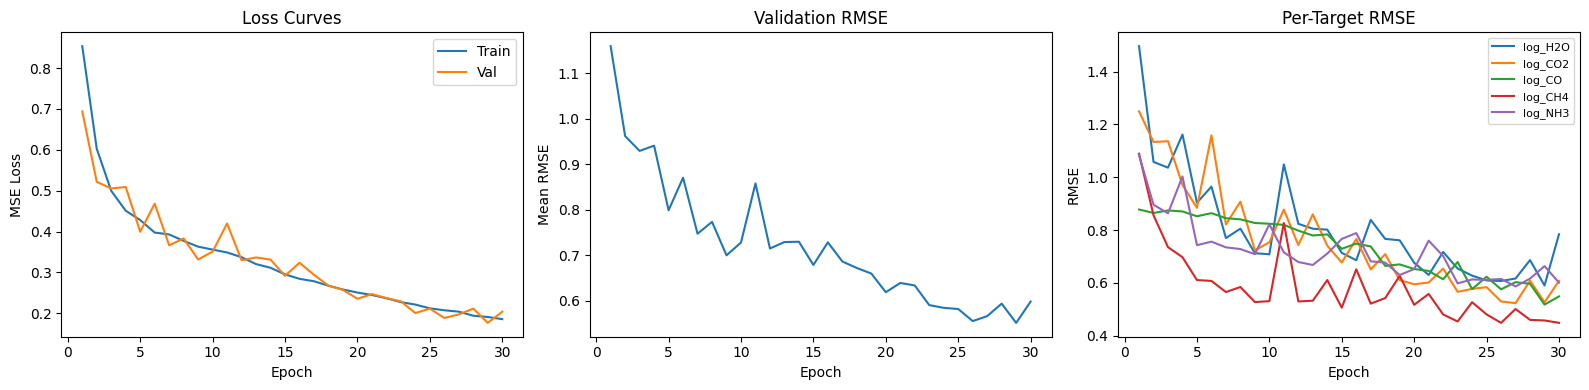

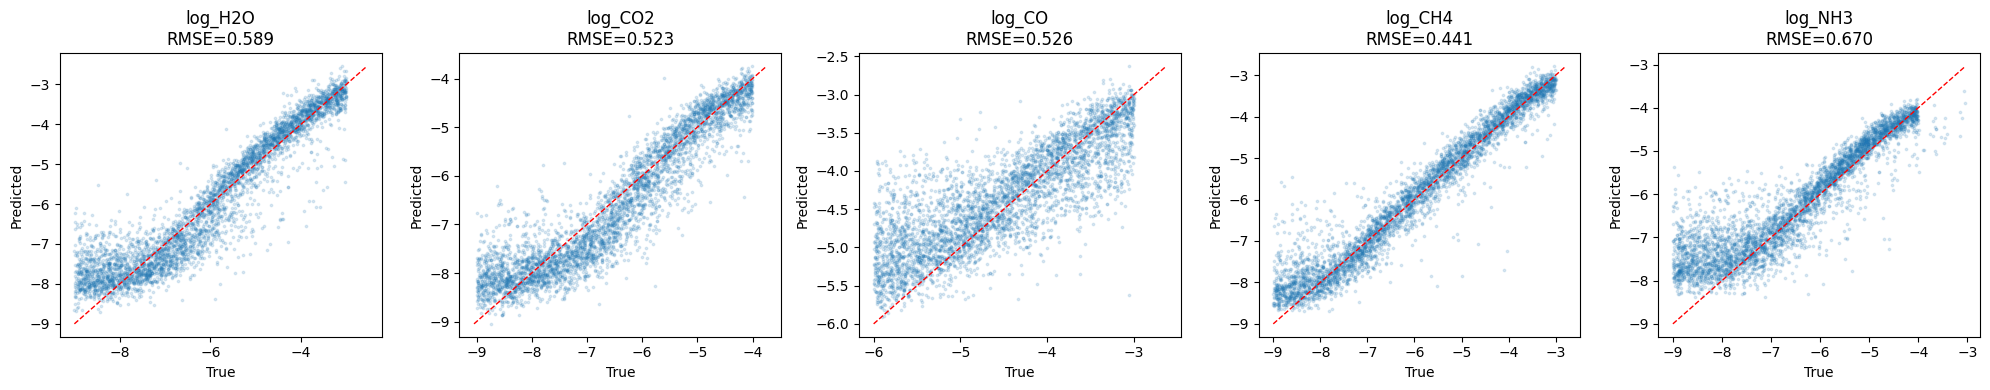

In [9]:
test_loss, test_rmse, test_rmse_mean, test_pred = evaluate(test_aux, test_spec, test_tgt, test_raw_tgt)

print(f"Test Loss: {test_loss:.5f}")
print(f"Test RMSE (mean): {test_rmse_mean:.4f}")
print()
results_df = pd.DataFrame({"target": TARGET_COLS, "RMSE": test_rmse})
display(results_df)

hf = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(hf["epoch"], hf["train_loss"], label="Train")
axes[0].plot(hf["epoch"], hf["val_loss"], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()

axes[1].plot(hf["epoch"], hf["val_rmse_mean"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean RMSE")
axes[1].set_title("Validation RMSE")

for col in TARGET_COLS:
    axes[2].plot(hf["epoch"], hf[f"rmse_{col}"], label=col)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("RMSE")
axes[2].set_title("Per-Target RMSE")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (col, ax) in enumerate(zip(TARGET_COLS, axes)):
    true = test_raw_tgt[:, i]
    pred = test_pred[:, i]
    ax.scatter(true, pred, alpha=0.15, s=3)
    lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{col}\nRMSE={test_rmse[i]:.3f}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "scatter_predictions.png", dpi=150)
plt.show()

## 6. Save Artifacts

In [10]:
torch.save(
    {
        "feature_cols": AUX_FEATURE_COLS,
        "target_cols": TARGET_COLS,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "model_state_dict": best_state,
        "ablation": "test1_identity_no_vqc",
        "latent_dim": LATENT_DIM,
    },
    OUTPUT_DIR / "best_model.pt",
)

scalers = {
    "aux": {"mean": aux_mean.tolist(), "scale": aux_scale.tolist()},
    "target": {"mean": target_mean.tolist(), "scale": target_scale.tolist()},
    "spectral": {"mean": spec_mean.tolist(), "scale": spec_scale.tolist()},
}
(OUTPUT_DIR / "scalers.json").write_text(json.dumps(scalers, indent=2))

hf.to_csv(OUTPUT_DIR / "history.csv", index=False)

pred_df = pd.DataFrame({"planet_ID": labels.iloc[test_idx]["planet_ID"].values})
for i, col in enumerate(TARGET_COLS):
    pred_df[f"true_{col}"] = test_raw_tgt[:, i]
    pred_df[f"pred_{col}"] = test_pred[:, i]
pred_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

summary = {
    "test_name": "Test 1 Identity Ablation",
    "description": "No-VQC identity mapping with the same head input structure and residual path as the hybrid baseline.",
    "best_epoch": best_epoch,
    "best_val_loss": float(best_val_loss),
    "test_loss": float(test_loss),
    "test_rmse_mean": float(test_rmse_mean),
    "test_rmse": {name: float(value) for name, value in zip(TARGET_COLS, test_rmse)},
}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2))

print(f"Artifacts saved to {OUTPUT_DIR.resolve()}/")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name} ({f.stat().st_size / 1024:.0f} KB)")

Artifacts saved to /Users/jkw/Documents/uni/axion/hack4sages/outputs/no_vqc_test1/
  best_model.pt (220 KB)
  history.csv (5 KB)
  scalers.json (4 KB)
  scatter_predictions.png (496 KB)
  summary.json (0 KB)
  test_predictions.csv (466 KB)
  training_curves.png (155 KB)
